In [3]:
import pandas as pd
import numpy as np

# Generate dataset
np.random.seed(42)

X = np.arange(1, 101)

# Polynomial relationship with slight noise
Y = 0.5 * (X**2) + 3 * X + 10 + np.random.randint(-50, 50, size=100)

# Create DataFrame
df = pd.DataFrame({
    'X': X,
    'Y': Y
})

# Display first rows
print(df.head())

   X     Y
0  1  14.5
1  2  60.0
2  3 -12.5
3  4  51.0
4  5  47.5


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df.isnull().sum()

,0
X,0
Y,0


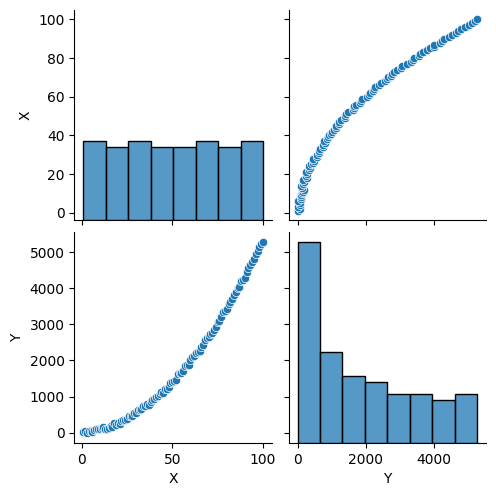

In [6]:
sns.pairplot(df)

In [42]:
# Fitting the model
from sklearn.preprocessing import PolynomialFeatures

ploy = PolynomialFeatures(degree=2)
X_poly = ploy.fit_transform(df[['X']])


Using Train-Test-Split

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x_train,x_test,y_train,y_test = train_test_split(X_poly,df['Y'],test_size=0.2,random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

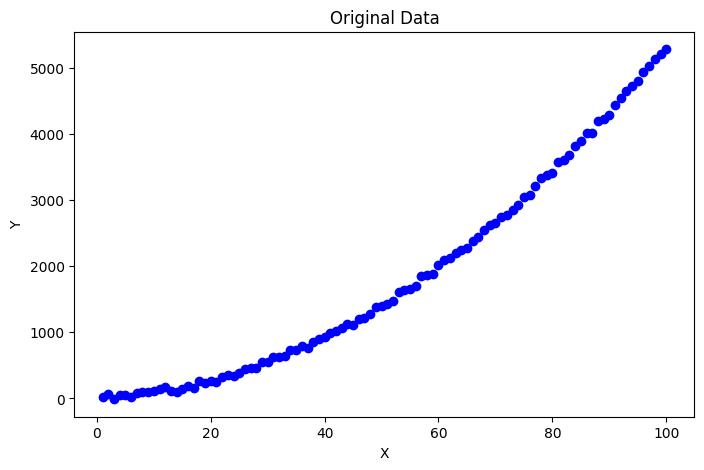

In [59]:

plt.figure(figsize=(8,5))
plt.scatter(df['X'], df['Y'], color='blue')
plt.title("Original Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [47]:
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


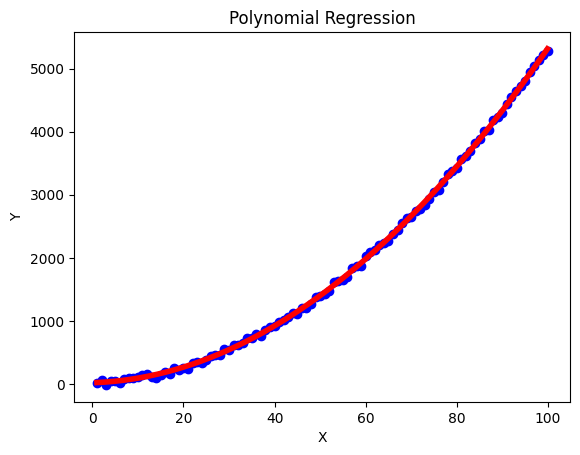

In [57]:
X_grid = np.arange(min(df['X'].values), max(df['X'].values), 0.1)

X_grid = X_grid.reshape(-1, 1)

X_grid_poly = poly.transform(X_grid)

# Polynomial Curve
plt.scatter(df['X'],df['Y'],color="blue")
plt.plot(
    X_grid,
    model.predict(X_grid_poly),
    color='red',
    linewidth=4

)

plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [21]:
# Evaluation metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [51]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [52]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 22.42531464810219
Mean Squared Error: 746.0328350054192
Root Mean Squared Error: 27.31360164836229
R-squared: 0.9996425989572029


In [53]:
# Coeffient and Intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [0.         2.2244516  0.50759681]
Intercept: 22.4211278722737


In [61]:

# Train and Test Accuracy

# Training Accuracy
train_accuracy = model.score(x_train, y_train)

# Testing Accuracy
test_accuracy = model.score(x_test, y_test)

print("\nTraining Accuracy :", train_accuracy)

print("Testing Accuracy  :", test_accuracy)


Training Accuracy : 0.9996742394469114
Testing Accuracy  : 0.9996425989572029
